In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import sqlite3

print("All libraries ready!")

All libraries ready!


In [3]:
import pandas as pd

df = pd.read_csv(r'C:\Users\HP\Downloads\water_potability.csv')
print(df.shape)
print(df.head())

(3276, 10)
         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  


In [4]:
# Check basic info
print(df.info())
print("\n")

# Check missing values
print("Missing Values:")
print(df.isnull().sum())
print("\n")

# Check target distribution
print("Potability Distribution:")
print(df['Potability'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB
None


Missing Values:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


Potability Distributi

C:\Users\HP\AppData\Local\Temp\ipykernel_27480\2601101212.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Potability', data=df, palette='Set2')


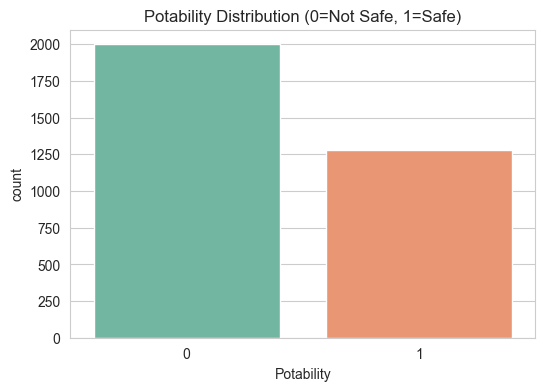

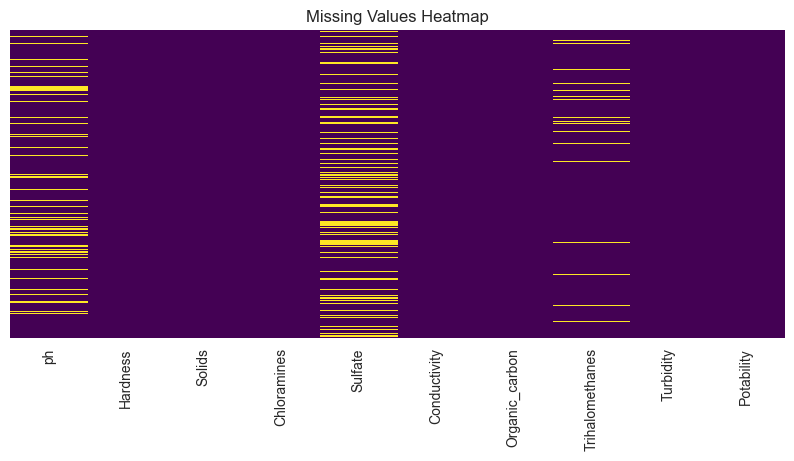

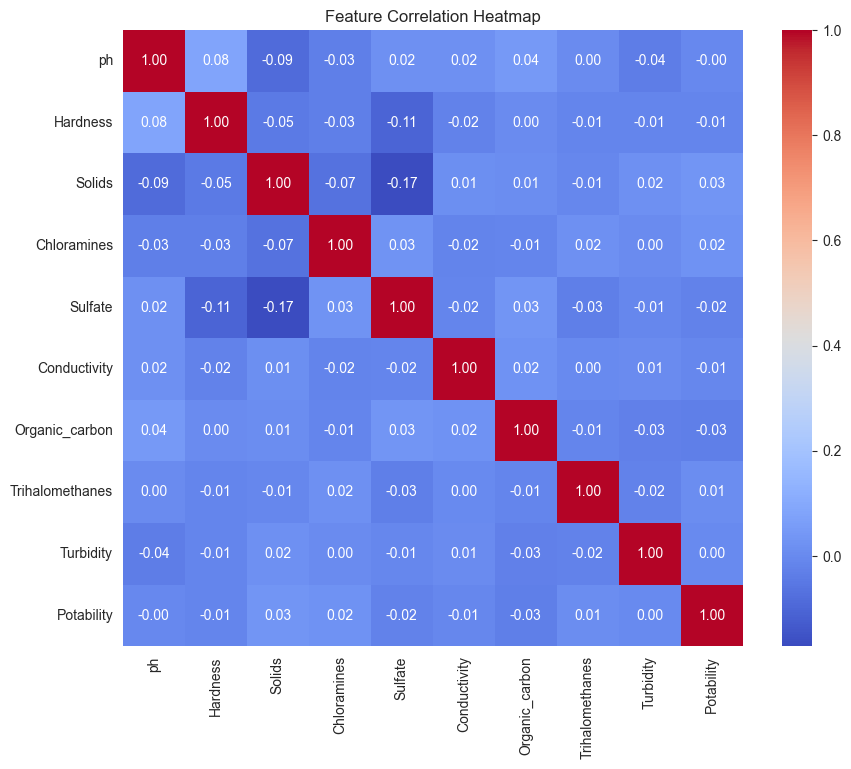

In [5]:
# Set style
sns.set_style("whitegrid")

# 1. Potability distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Potability', data=df, palette='Set2')
plt.title('Potability Distribution (0=Not Safe, 1=Safe)')
plt.savefig('potability_distribution.png')
plt.show()

# 2. Missing values heatmap
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.savefig('missing_values.png')
plt.show()

# 3. Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()

In [6]:
# Fill missing values with median (better than mean for skewed data)
df['ph'].fillna(df['ph'].median(), inplace=True)
df['Sulfate'].fillna(df['Sulfate'].median(), inplace=True)
df['Trihalomethanes'].fillna(df['Trihalomethanes'].median(), inplace=True)

# Confirm no missing values remain
print("Missing values after cleaning:")
print(df.isnull().sum())
print("\nData cleaning complete!")

Missing values after cleaning:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

Data cleaning complete!


C:\Users\HP\AppData\Local\Temp\ipykernel_27480\254559118.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['ph'].fillna(df['ph'].median(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_27480\254559118.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

In [7]:
import sqlite3

# Create a database and store the cleaned data
conn = sqlite3.connect('water_quality.db')
df.to_sql('water_data', conn, if_exists='replace', index=False)

# Query 1 - Total safe vs unsafe water samples
query1 = pd.read_sql_query("""
    SELECT Potability, COUNT(*) as Total_Samples
    FROM water_data
    GROUP BY Potability
""", conn)
print("Safe vs Unsafe Water Samples:")
print(query1)

# Query 2 - Average ph of safe vs unsafe water
query2 = pd.read_sql_query("""
    SELECT Potability, 
           ROUND(AVG(ph), 2) as Avg_pH,
           ROUND(AVG(Sulfate), 2) as Avg_Sulfate,
           ROUND(AVG(Turbidity), 2) as Avg_Turbidity
    FROM water_data
    GROUP BY Potability
""", conn)
print("\nAverage Features by Potability:")
print(query2)

conn.close()
print("\nSQL queries complete!")

Safe vs Unsafe Water Samples:
   Potability  Total_Samples
0           0           1998
1           1           1278

Average Features by Potability:
   Potability  Avg_pH  Avg_Sulfate  Avg_Turbidity
0           0    7.08       334.20           3.97
1           1    7.07       332.68           3.97

SQL queries complete!


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split features and target
X = df.drop('Potability', axis=1)
y = df['Potability']

# Split into train and test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

# Build Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Results
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training samples: 2620
Testing samples: 656

Model Accuracy: 67.38%

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.85      0.77       412
           1       0.60      0.38      0.46       244

    accuracy                           0.67       656
   macro avg       0.65      0.61      0.61       656
weighted avg       0.66      0.67      0.65       656



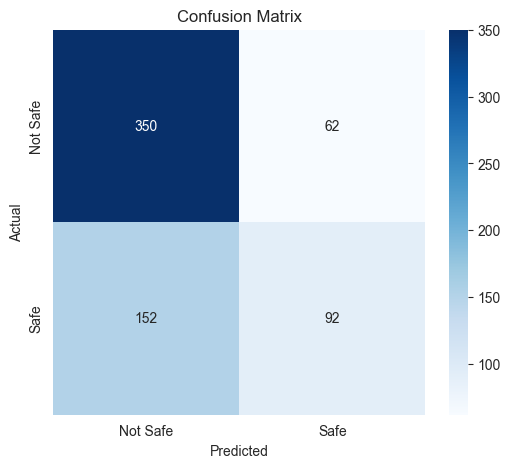

C:\Users\HP\AppData\Local\Temp\ipykernel_27480\654279172.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')


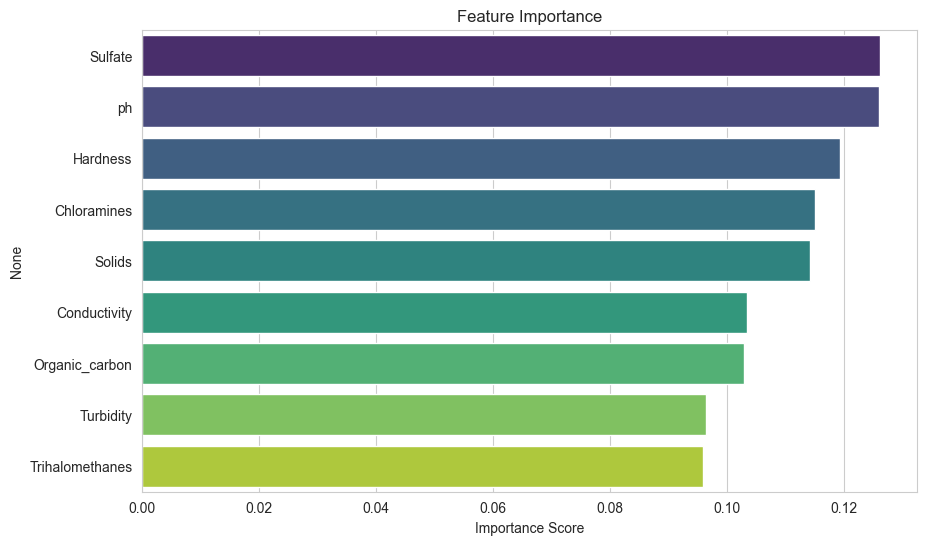

Top 3 most important features:
Sulfate     0.126330
ph          0.126106
Hardness    0.119346
dtype: float64


In [9]:
# Confusion Matrix
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Safe', 'Safe'],
            yticklabels=['Not Safe', 'Safe'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')
plt.show()

# Feature Importance
plt.figure(figsize=(10,6))
feature_importance = pd.Series(model.feature_importances_, 
                                index=X.columns).sort_values(ascending=False)
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='viridis')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.savefig('feature_importance.png')
plt.show()

print("Top 3 most important features:")
print(feature_importance.head(3))

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split again
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Improved Random Forest with better parameters
model2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)
model2.fit(X_train, y_train)
y_pred2 = model2.predict(X_test)

accuracy2 = accuracy_score(y_test, y_pred2)
print(f"Improved Accuracy: {accuracy2*100:.2f}%")

Improved Accuracy: 67.84%


In [11]:
from sklearn.ensemble import GradientBoostingClassifier

# Gradient Boosting - often better than Random Forest
model3 = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
model3.fit(X_train, y_train)
y_pred3 = model3.predict(X_test)

accuracy3 = accuracy_score(y_test, y_pred3)
print(f"Gradient Boosting Accuracy: {accuracy3*100:.2f}%")

Gradient Boosting Accuracy: 65.09%


In [12]:
# Export cleaned data for Tableau
df.to_csv(r'C:\Users\HP\Downloads\water_cleaned.csv', index=False)
print("Exported successfully!")

Exported successfully!
